In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
base = "/home/jainv/my_projects/customer-lifetime-value-churn-prediction/"
path = base+"Telco-Customer-Churn.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Columns, Missing values and dtype:")
print(df.info())

Columns, Missing values and dtype:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperle

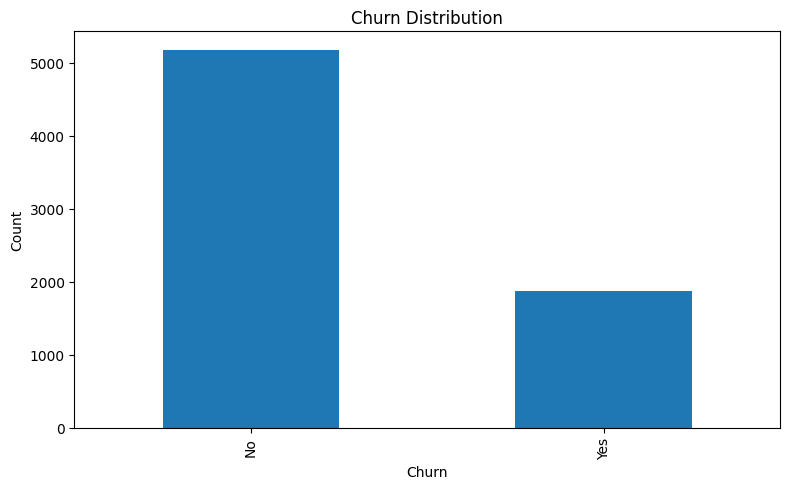

In [4]:
# Overall churn rate and dataset imbalance
plt.figure(figsize=(8,5))
df["Churn"].value_counts().plot(kind="bar")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig(base+"plots/churn_rate.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

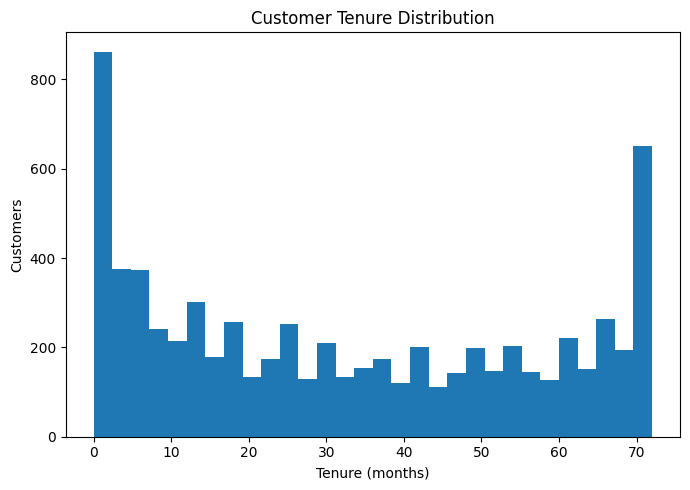

In [5]:
# Customer lifetime spread
plt.figure(figsize=(7,5))
plt.hist(df["tenure"], bins=30)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (months)")
plt.ylabel("Customers")
plt.tight_layout()
plt.savefig(base+"plots/cust_tenure_dist.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

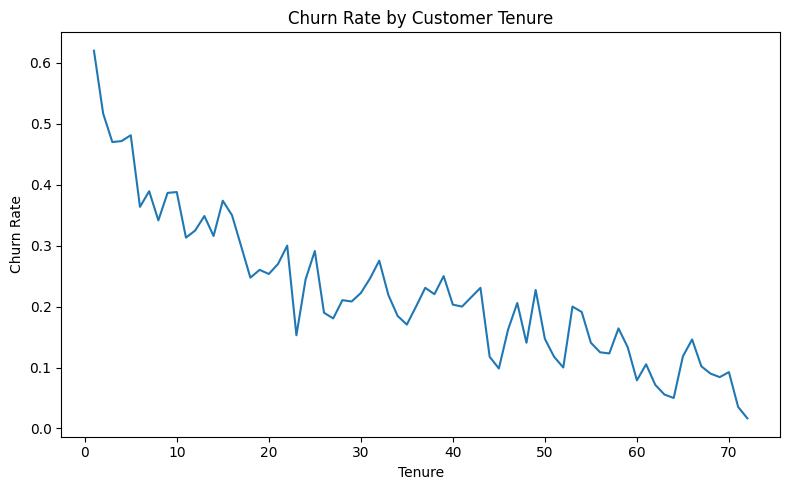

In [ ]:
tenure_churn = df.groupby("tenure")["Churn"].mean()

plt.figure(figsize=(8,5))
plt.plot(tenure_churn)
plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.savefig(base+"plots/tenure_churn.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Customers with short tenure churn more

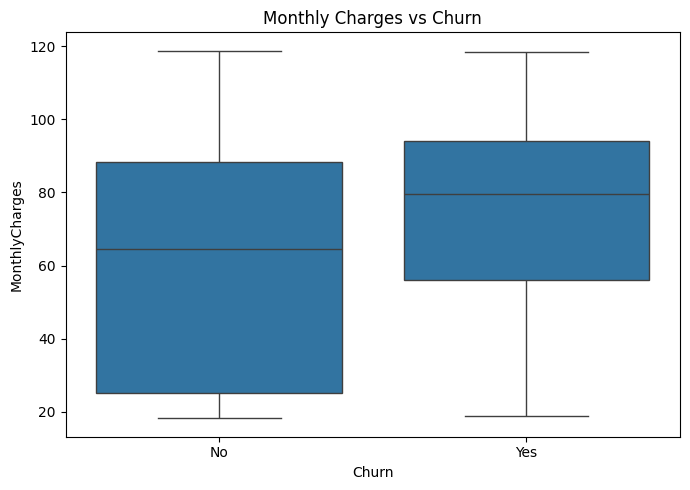

In [6]:
# High paying customers churn more

plt.figure(figsize=(7,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.tight_layout()
plt.savefig(base+"plots/chgs_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

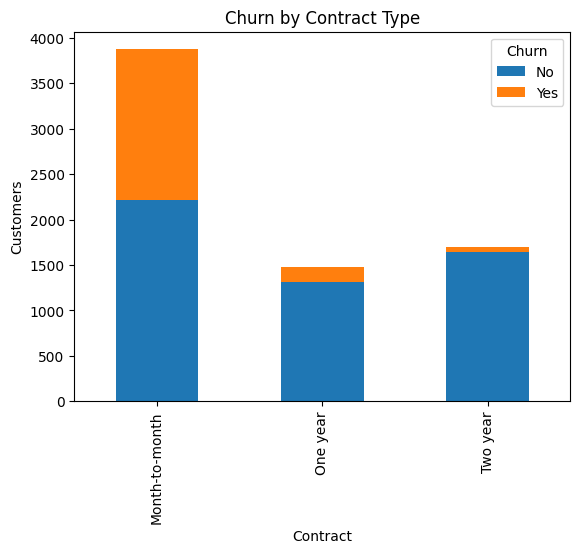

In [7]:
# Long contracts reduce churn
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Customers")
plt.show()

In [8]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing
df = df.dropna()

# Convert target to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Drop ID column
df = df.drop(columns=["customerID"])

# Encode Categorical Variables
cat_cols = df.select_dtypes(include="object").columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Target Split
X = df.drop(columns=["Churn"])
y = df["Churn"]


# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size: ", X_train.shape)
print("Test size: ", X_test.shape)

Train size:  (5625, 19)
Test size:  (1407, 19)


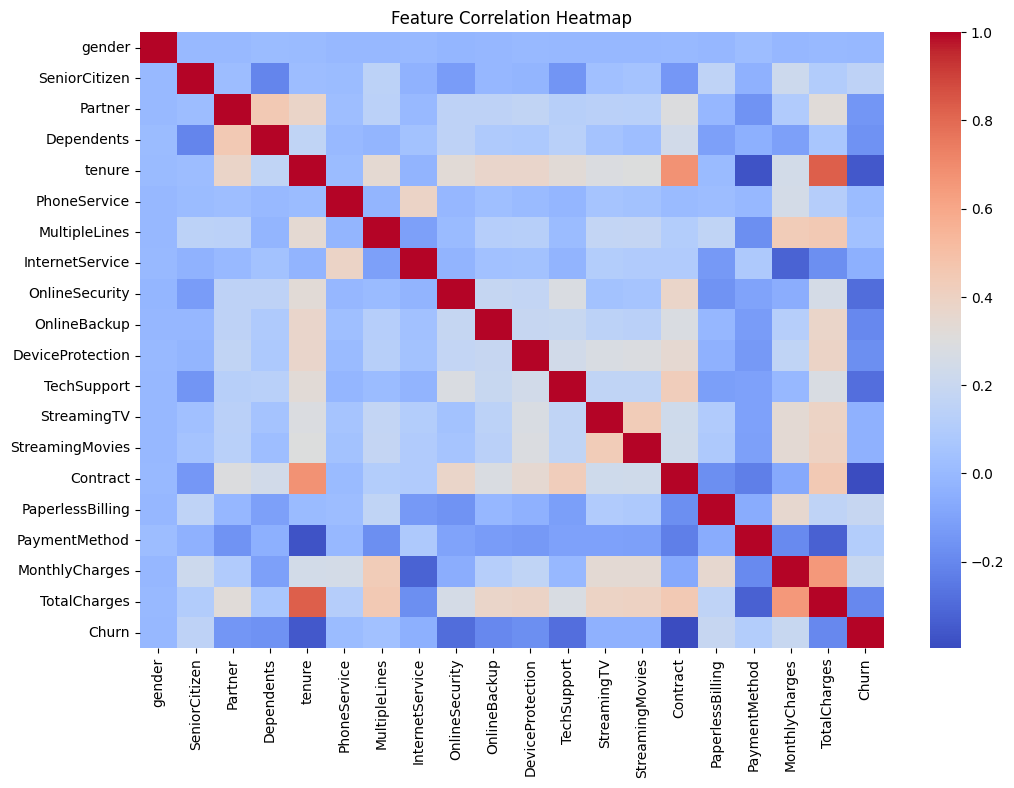

In [9]:
# What are strongest churn predictors
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [10]:
# Gradient Boosting Model (XGBoost)
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("CHURN MODEL")
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

CHURN MODEL
ROC-AUC: 0.8250022001232069
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



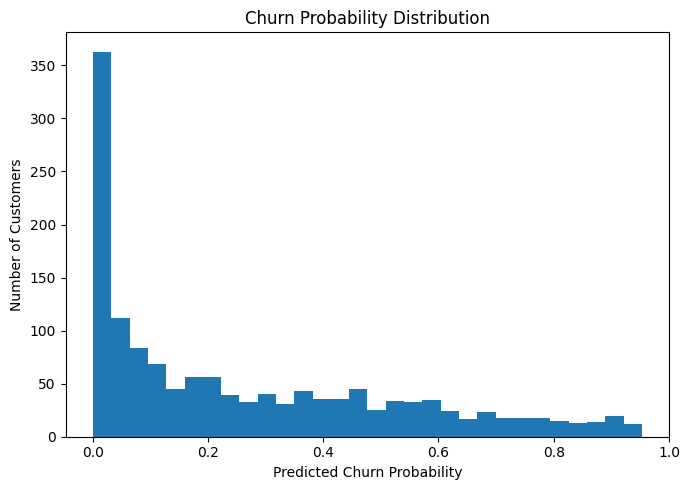

In [11]:
plt.figure(figsize=(7,5))
plt.hist(y_pred_proba, bins=30)
plt.title("Churn Probability Distribution")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(base+"plots/churn_proba.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [12]:
# Survival Analysis (Cox Model)

# Using tenure as duration
df["duration"] = df["tenure"]

# Event = churn
df["event"] = df["Churn"]

survival_df = df.drop(columns=["Churn"])

cph = CoxPHFitter()
cph.fit(survival_df, duration_col="duration", event_col="event")

print("COX MODEL SUMMARY")
cph.summary

COX MODEL SUMMARY


/usr/local/lib/python3.11/site-packages/lifelines/utils/__init__.py:1163: ConvergenceWarning: Column tenure has high sample correlation with the duration column. This may harm convergence. This could be a form of 'complete separation'.     See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/usr/local/lib/python3.11/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
gender,-0.007895,0.992136,0.046390,-0.098817,0.083028,0.905908,1.086572,0.0,-0.170182,8.648667e-01,0.209450
SeniorCitizen,0.118670,1.125998,0.056674,0.007592,0.229748,1.007621,1.258283,0.0,2.093919,3.626718e-02,4.785191
Partner,-0.007161,0.992864,0.055377,-0.115698,0.101376,0.890744,1.106692,0.0,-0.129317,8.971071e-01,0.156648
Dependents,-0.087558,0.916165,0.068051,-0.220936,0.045819,0.801768,1.046885,0.0,-1.286664,1.982116e-01,2.334887
tenure,-0.436063,0.646577,0.011671,-0.458939,-0.413188,0.631954,0.661538,0.0,-37.361791,1.631633e-305,1012.481752
PhoneService,-0.708639,0.492314,0.113995,-0.932065,-0.485214,0.393740,0.615566,0.0,-6.216425,5.086088e-10,30.872725
MultipleLines,0.014752,1.014861,0.028324,-0.040762,0.070266,0.960057,1.072794,0.0,0.520830,6.024851e-01,0.731002
InternetService,0.168652,1.183708,0.053022,0.064730,0.272573,1.066871,1.313339,0.0,3.180781,1.468787e-03,9.411159
OnlineSecurity,-0.191022,0.826114,0.033066,-0.255830,-0.126215,0.774274,0.881425,0.0,-5.777081,7.600748e-09,26.971211


In [13]:
# Concordance Index
c_index = concordance_index(
    survival_df["duration"],
    -cph.predict_partial_hazard(survival_df),
    survival_df["event"]
)

print("Concordance Index:", c_index)

Concordance Index: 0.9873373604120019


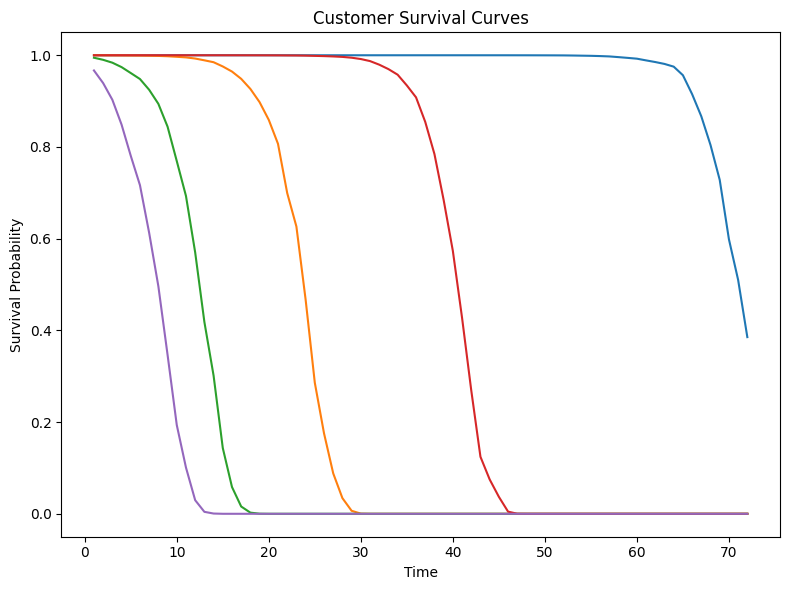

In [20]:
sample = X_test.iloc[:5]
survival = cph.predict_survival_function(sample)

plt.figure(figsize=(8,6))
for i in survival.columns:
    plt.plot(survival.index, survival[i])

plt.title("Customer Survival Curves")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.tight_layout()
plt.savefig(base+"plots/survival_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [15]:
# CLV Calculation

# Monthly revenue
df["monthly_value"] = df["MonthlyCharges"]

# Expected lifetime approximation
hazard = cph.predict_partial_hazard(X)
df["expected_lifetime"] = 365 / (1 + hazard)

# CLV
df["CLV"] = df["expected_lifetime"] * df["monthly_value"]

print("CLV SAMPLE")
print(df[["CLV"]].head())

CLV SAMPLE
            CLV
0      0.010183
1  16649.929174
2      0.058851
3  15406.489968
4      0.029334


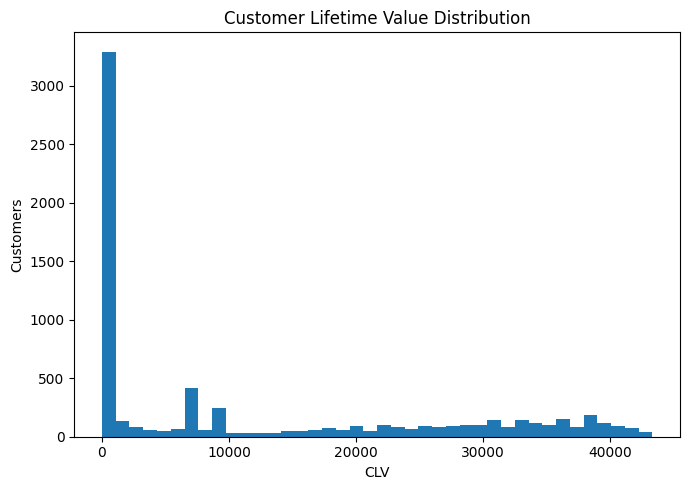

In [16]:
# high value customer outliers
plt.figure(figsize=(7,5))
plt.hist(df["CLV"], bins=40)
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("Customers")
plt.tight_layout()
plt.savefig(base+"plots/clv_dist_plot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# The CLV distribution shows a highly right-skewed pattern where most customers have low lifetime value, 
# while a small segment contributes disproportionately high revenue. 
# This suggests retention efforts should prioritize high-CLV customers to maximize ROI.

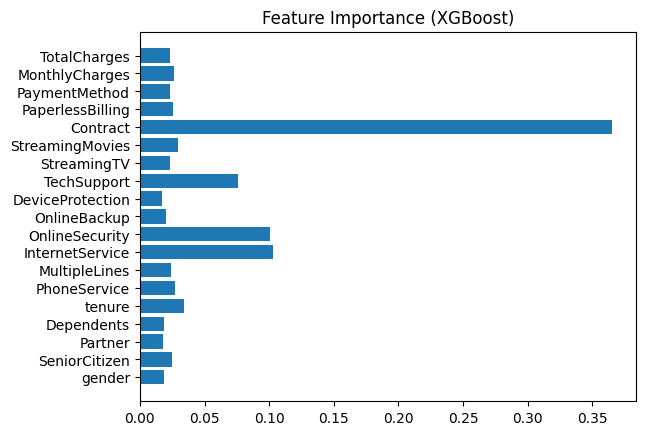

In [17]:
# Feature Importance
importance = model.feature_importances_
plt.barh(X.columns, importance)
plt.title("Feature Importance (XGBoost)")
plt.show()